## 1. Loading the Data

### 1.1 Importing the data
- **NumPy** (`numpy`): Handles numerical operations and arrays. We'll use it for things like random number generation and array manipulation.

- **Pandas** (`pandas`): Provides data structures like DataFrames for working with tabular data. We'll use it to load, explore, and manipulate our dataset.

- **Scikit-Learn** (`sklearn`): The main machine learning library. We'll use it for modeling, evaluation, and preprocessing.

We'll import other libraries as we need them throughout the project.





In [41]:
# Imports.
import numpy as np 
import pandas as pd

In [42]:
#Loading the data and see how it looks like
df = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv")
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



# Understand the data always !
| Column | What it stands for | What it measures |
| :--- | :--- | :--- |
| **age** | Age in years | How old the patient is |
| **sex** | Sex | 1 = male, 0 = female |
| **cp** | Chest pain type | 0: Typical angina, 1: Atypical angina, 2: Non-anginal pain, 3: Asymptomatic |
| **trestbps** | Resting blood pressure | In mm Hg (on admission to the hospital) |
| **chol** | Cholesterol | Serum cholesterol in mg/dl |
| **fbs** | Fasting blood sugar | > 120 mg/dl (1 = true; 0 = false) |
| **restecg** | Resting ECG results | 0: Normal, 1: ST-T wave abnormality, 2: Left ventricular hypertrophy |
| **thalach** | Maximum heart rate achieved | How high their heart rate got during exercise |
| **exang** | Exercise induced angina | 1 = yes, 0 = no (chest pain during exercise) |
| **oldpeak** | ST depression | The heart not getting enough oxygen during exercise |
| **slope** | Slope of peak exercise ST segment | 0: Upsloping, 1: Flatsloping, 2: Downsloping |
| **ca** | Number of major vessels | 0-3 colored by fluoroscopy |
| **thal** | Thalium stress result | 1: Normal, 3: Normal, 6: Fixed defect, 7: Reversible defect |
| **target** | Heart disease diagnosis | 1 = has disease, 0 = no disease |


* So the data contains 14 columns, 13 of them are features(input variables) and 1 target (ouput variable)

In [43]:
# Any missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [44]:
"""
1.Understanding what this function value_counts() does:
the goal of this functions takes a column and try to see the different type and values of that column/row
"""

#Notice how our data is not perfectly balanced because we have more people who have heart disease than people 
#who do not have heart disease, but even so, it is not incredibly unbalanced. This is a good thing because if it was really unbalanced, 
# then it would predict wrongly because it won't be able to see hidden patterns perfectly, for example. btw 303 samples

'\n1.Understanding what this function value_counts() does:\nthe goal of this functions takes a column and try to see the different type and values of that column/row\n'

In [45]:
#Can also normalized,
df['target'].value_counts(normalize=True) *100
"""
This is how it is easy to say: maybe if you do a bell curve, it's going to be skewed because you have more heart 
disease than no heart disease. Remember, this is a categorical, in other words binary, classification of having 
heart disease or not having heart disease, meaning that you cannot use a bell curve of a normal distribution. 
For example, even if it is cute, it is only applied for discrete continuous value, not for categorical value. 
"""

"\nThis is how it is easy to say: maybe if you do a bell curve, it's going to be skewed because you have more heart \ndisease than no heart disease. Remember, this is a categorical, in other words binary, classification of having \nheart disease or not having heart disease, meaning that you cannot use a bell curve of a normal distribution. \nFor example, even if it is cute, it is only applied for discrete continuous value, not for categorical value. \n"

# Section: visualizing the data 

In this section, we will create visualizations to better understand the relationship between each feature and the target variable. Visualizing the data helps us spot patterns, outliers, and potential relationships that a summary statistic alone might miss. Meaning that if you just try to summarize the whole picture, you might not see certain hidden patterns. This section, I am going to use Matplotlib to plot data and visualize data, but we're also going to use the Seaborn library to be able to visualize data in a prettier way. Instead of just using Matplotlib, which often requires a lot of work to do when we try to make things look pretty. 

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

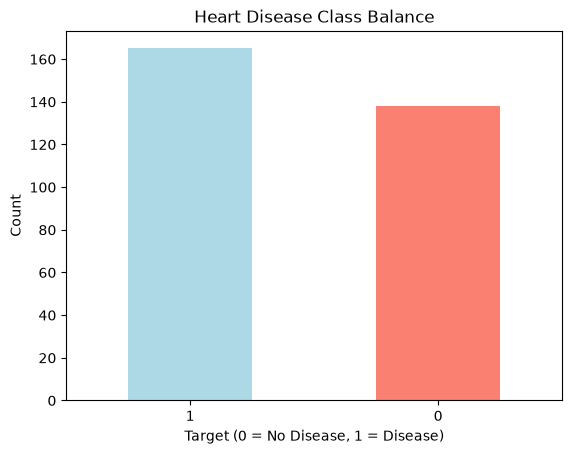

In [56]:
df['target'].value_counts().plot(kind='bar',color=['lightblue', 'salmon'])
plt.title("Heart Disease Class Balance")
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

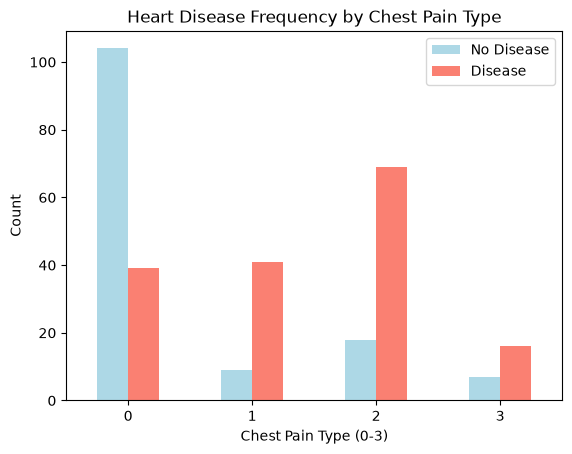

In [58]:
# How does chest pain relate to heart disease
# Create a crosstab of chest pain type vs. target


pd.crosstab(df['cp'],df['target']).plot(kind='bar',color=['lightblue', 'salmon'])
plt.title('Heart Disease Frequency by Chest Pain Type')
plt.xlabel('Chest Pain Type (0-3)')
plt.ylabel('Count')
plt.legend(['No Disease', 'Disease'])
plt.xticks(rotation=0)
plt.show()

In [59]:
pd.crosstab(df['cp'],df['target']).value_counts()

0    1 
104  39    1
9    41    1
18   69    1
7    16    1
Name: count, dtype: int64